# Libraries
### Make sure these libraries are installed in order to successfully run this script

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr # Using for Spearman Rank Correlation
import scipy.stats as stats

# Calculate Spearman Rank Correlation

In [ ]:
# Retrive CSV from cyberduck using path
et = pd.read_csv("/capstone/aridgw/outputs/1km/site_summary_1km2.csv")

# Calculate Spearman Rank
rho, p_value = spearmanr(et['gw_trend_m_per_yr'], et['et_precip_ratio'])


print(f"Spearman's Calculation: rho = {rho:.3f}, p = {p_value:.3f}")


Spearman's Calculation: rho = 0.528, p = 0.000


# Creating a scatterplot to view how the 50 sites are distributed

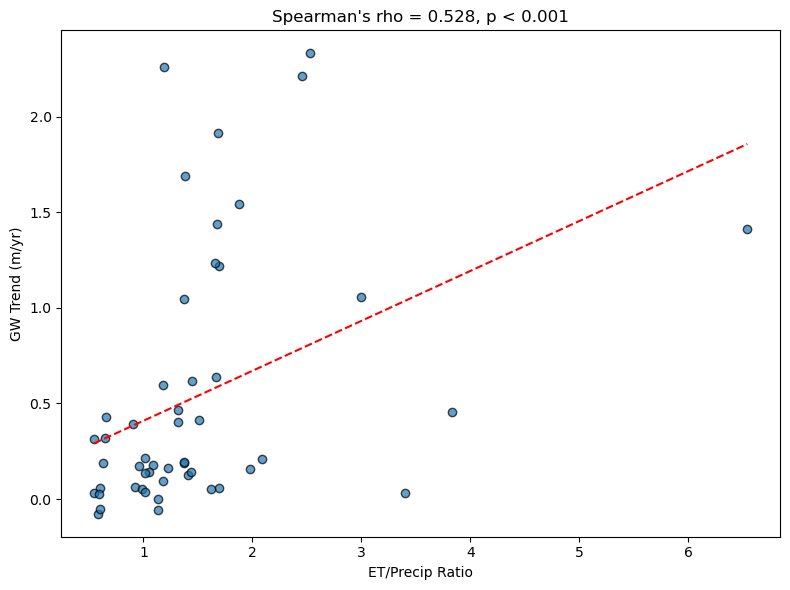

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(et['et_precip_ratio'], et['gw_trend_m_per_yr'], alpha=0.7, edgecolors= "black", linewidths= 1)

# regression line
m, b, *_ = stats.linregress(et['et_precip_ratio'], et['gw_trend_m_per_yr'])
x = np.linspace(et['et_precip_ratio'].min(), et['et_precip_ratio'].max(), 100)
ax.plot(x, m * x + b, 'r--')

ax.set_xlabel('ET/Precip Ratio')
ax.set_ylabel('GW Trend (m/yr)')
ax.set_title(f"Spearman's rho = 0.528, p < 0.001")

plt.tight_layout()

#plt.savefig("spearman_overall.png", dpi=150)

# Calculate the Spearman Rank Correlation per Region

In [ ]:
for region, group in et.groupby('region'):
    if len(group) < 3:  # skip regions with too few points
        continue
    rho, p = spearmanr(group['gw_trend_m_per_yr'], group['et_precip_ratio'])

    
    print(f"{region}: rho = {rho:.3f}, p = {p:.3f}, n = {len(group)}")

Arkansas Delta: rho = 0.750, p = 0.052, n = 7
Central Nebraska: rho = 0.286, p = 0.535, n = 7
SoCal_Arizona: rho = 0.667, p = 0.071, n = 8
Southern Idaho: rho = -0.400, p = 0.600, n = 4
Southern Kansas: rho = 0.830, p = 0.003, n = 10
Western Texas: rho = 0.850, p = 0.004, n = 9
Western Utah: rho = 0.200, p = 0.747, n = 5


# Plot Scatterplot 

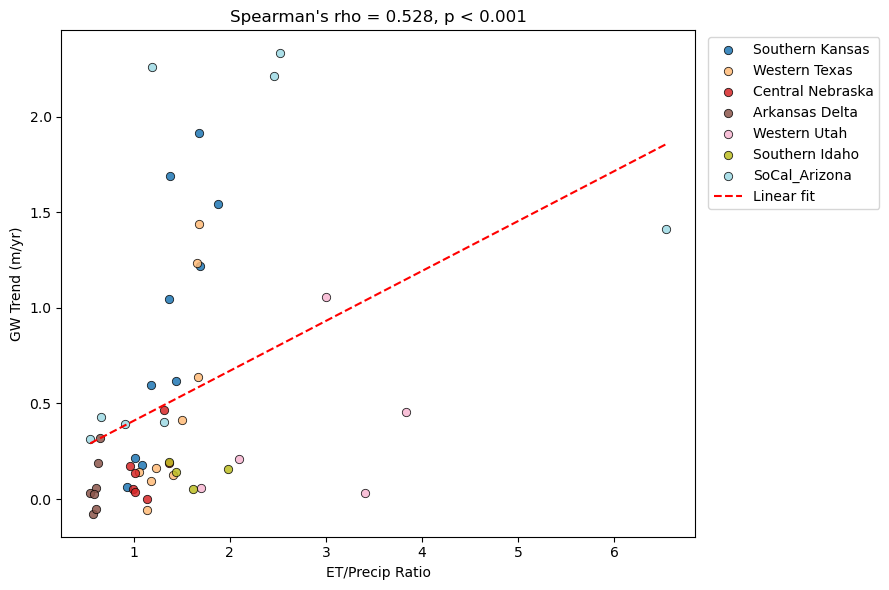

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

regions = et['region'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(regions)))

for region, color in zip(regions, colors):
    subset = et[et['region'] == region]
    ax.scatter(subset['et_precip_ratio'], subset['gw_trend_m_per_yr'], 
               label=region, color=color, alpha=0.85, edgecolors= "black", linewidths= 0.6)

# regression line
m, b, *_ = stats.linregress(et['et_precip_ratio'], et['gw_trend_m_per_yr'])
x = np.linspace(et['et_precip_ratio'].min(), et['et_precip_ratio'].max(), 100)
ax.plot(x, m * x + b, 'r--', label='Linear fit')

ax.set_xlabel('ET/Precip Ratio')
ax.set_ylabel('GW Trend (m/yr)')
ax.set_title(f"Spearman's rho = 0.528, p < 0.001")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()

#plt.savefig("spearman_overall.png", dpi=150, bbox_inches='tight')